In [1]:
import re
import itertools
from pathlib import Path
import scipy
from matplotlib import pyplot as plt
import numpy as np
import math
from scipy.io import loadmat
import pandas as pd
from typing import Any, Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:

def _matlab_length(x):
    """
    MATLAB length(x): max(size(x)) for arrays.
    For Python objects/lists, use len().
    """
    if x is None:
        return 0
    if isinstance(x, (list, tuple)):
        return len(x)
    try:
        a = np.asarray(x)
        if a.ndim == 0:
            return 1
        return int(max(a.shape))
    except Exception:
        return 1

def _index_like_matlab_vector(x, trials_bool):
    """
    MATLAB: x(trials_bool)
    Works for numpy arrays (including dtype=object) and python lists.
    """
    if isinstance(x, list):
        return [xi for xi, keep in zip(x, trials_bool) if keep]
    a = np.asarray(x)
    # ensure 1D behavior like a vector/cell array
    a = a.ravel()
    return a[trials_bool]

def selectBehaviorTrials(bhv, trials, nTrials=None):
    """
    Faithful translation of your MATLAB selectBehaviorTrials for the common case:
    trials is a logical vector (useIdx).
    Includes the crucial 'struct one layer deeper' behavior, so RawEvents.Trial is sliced.
    """

    # --- fieldnames ---
    if bhv is None:
        return bhv
    bFields = list(getattr(bhv, "_fieldnames", []))

    # --- nTrials handling (MATLAB: if isfield(bhv,'nTrials') ...) ---
    if hasattr(bhv, "nTrials"):
        bhv.nTrials = int(np.sum(np.asarray(bhv.nTrials)))
        nTrials = bhv.nTrials
    elif nTrials is None:
        raise ValueError("Need nTrials if bhv has no nTrials field")

    trials = np.asarray(trials, dtype=bool).ravel()

    # MATLAB: if length(trials) ~= nTrials → warning + truncate
    if trials.size != nTrials:
        warnings.warn("Trial index has different length as available trials in behavioral dataset")
        trials = trials[:nTrials]

    # MATLAB: if isfield(bhv,'nTrials') bhv.nTrials = sum(trials);
    if hasattr(bhv, "nTrials"):
        bhv.nTrials = int(np.sum(trials))

    # --- main loop over fields ---
    for fname in bFields:
        val = getattr(bhv, fname)

        # MATLAB: if ~any(ismember(size(val), length(trials))) ...
        # We'll treat "contains trial dimension" as: any dimension equals nTrials
        try:
            shape = np.shape(val)
            contains_trial_dim = any(d == nTrials for d in shape)
        except Exception:
            contains_trial_dim = False

        if not contains_trial_dim:
            # MATLAB: if isstruct(val) check one layer deeper
            if hasattr(val, "_fieldnames"):
                tFields = list(getattr(val, "_fieldnames", []))
                if len(tFields) > 0:
                    first_sub = tFields[0]
                    inner = getattr(val, first_sub)

                    # MATLAB: if length(inner) == length(trials) then slice it
                    if _matlab_length(inner) == trials.size:
                        setattr(val, first_sub, _index_like_matlab_vector(inner, trials))
                        setattr(bhv, fname, val)
                    else:
                        # carry over whole field (do nothing)
                        pass
            else:
                # carry over whole field (do nothing)
                pass

        else:
            # MATLAB: if isvector(val) -> val(trials)
            # else: highD matrix -> slice along trial dimension
            arr = np.asarray(val)

            is_vector = (arr.ndim == 1) or (arr.ndim == 2 and 1 in arr.shape)
            if is_vector:
                setattr(bhv, fname, arr.ravel()[trials])
            else:
                # find first axis with size == nTrials (MATLAB: cIdx = find(...))
                axis = [i for i, d in enumerate(arr.shape) if d == nTrials][0]
                indexer = [slice(None)] * arr.ndim
                indexer[axis] = trials
                setattr(bhv, fname, arr[tuple(indexer)])

    return bhv

In [3]:
fpath = Path('../data/2975_LickingLama_20250207_125807.mat')

In [4]:
data = loadmat(
    fpath,
    squeeze_me=True,        # removes many (1,1) wrappers
    struct_as_record=False  # gives attribute-style access
)

data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Fri Feb  7 13:48:08 2025',
 '__version__': '1.0',
 '__globals__': [],
 'SessionData': <scipy.io.matlab._mio5_params.mat_struct at 0x252ede5c0d0>}

In [5]:
bhv  = data['SessionData']

In [6]:
save_path =  r"E:\GLM_project\EncoderResults"
Path(save_path).mkdir(parents=True, exist_ok=True)

In [7]:
opts = dict(
        skipIfExist=False,
        showOrthplot=False,
        preTrigDur=0.5,
        postTrigDur=8.0,
        nrFolds=20,
        testFrac=0.1,
        removeAutoTrials=True,
        innateTask=False,
        videoDims=100,
        preStimDur=0.2,
        postStimDur=3.0,
        preMoveDur=0.2,
        postMoveDur=3.0,
        cvRegs=["time", "choice", "prevChoice", "success", "prevSuccess", "water", "licks", "video"],
    )



In [8]:
import h5py

vc_path = Path('../data/Vc_2975.mat')
print(f"Loading variables from {vc_path}")

Loading variables from ..\data\Vc_2975.mat


In [9]:
with h5py.File(vc_path, 'r') as f:
    # Load the specific variables
    Vc = f['Vc'][:]
    trialOn = f['trialOn'][:]
    U = f['U'][:]
    ledInfo = f['ledInfo'][:] 
    frameInfo = f['frameInfo'][:]  
    
    print(f"Vc shape: {Vc.shape}")
    print(f"trialOn shape: {trialOn.shape}")
    print(f"U shape: {U.shape}")
    print(f"ledInfo shape: {ledInfo.shape}")
    print(f"frameInfo shape: {frameInfo.shape}") 

# Vc shape: (number of frames, number of components) 41623x500
# U shape: (number of pixels, number of components) 540x640x500
# frameInfo shape: (number of frames, time) 41623x2

Vc shape: (41623, 500)
trialOn shape: (3, 1000000)
U shape: (500, 640, 540)
ledInfo shape: (3, 41623)
frameInfo shape: (2, 41623)


In [10]:
trialOn_clean = trialOn[:, ~np.isnan(trialOn[0, :])]
trialOn_clean = trialOn_clean.T
trialOn_clean.shape

# trialOn_clean is now (number of valid trials, 3)
#  where the first column is frame number, 
# second column is trial start times and 
# the third column is trail number 

(274, 3)

### Aligning Trial Onsets to Imaging Frames

To align trial onsets with imaging data, we determine the **first imaging frame that occurs after each trial start time**.

#### Data Structure

- `frameInfo` (shape: *nFrames × 2*)
  - Column 1: Frame ID  
  - Column 2: Frame timestamp (in seconds)

- `trialOn_clean` (shape: *nTrials × 3*)
  - Column 1: Frame number (reference)
  - Column 2: Trial start time (in seconds)
  - Column 3: Trial number

#### Procedure

For each trial:

1. Take the trial start time.
2. Find the first frame whose timestamp is **strictly greater** than the trial start time.
3. Store the index of that frame.

In mathematical form:

$$
\text{trialOnFrames}[i] = \min \{ j \mid \text{frameTime}[j] > \text{trialStartTime}[i] \}
$$

#### Output

The resulting array `trialOnFrames` contains, for each trial, the index of the first imaging frame that occurs after trial onset.

This alignment step enables:
- Extraction of trial-aligned imaging windows  
- Baseline and post-stimulus analysis  
- Trial-averaged responses  
- Construction of design matrices for regression or encoding models  

In [11]:
nrTrials = trialOn_clean.shape[0]
trialOnFrames = np.zeros(nrTrials, dtype=np.int64)

if frameInfo.shape[0] == 2 and frameInfo.shape[1] > 2:
    frameInfo = frameInfo.T
    

t_frames = frameInfo[:, 1]  # time column

for i in range(nrTrials):
    t0 = trialOn_clean[i, 1]                 # trial start time (2nd column)
    idx = np.flatnonzero(t_frames > t0)  # rows where frame time is after t0
    trialOnFrames[i] = (idx[0] + 1) if idx.size else 0  # +1 to match MATLAB indexing

In [12]:
trialOnFrames[:10]  # print first 10 trial onset frames

array([ 103,  247,  387,  531,  657,  790,  933, 1085, 1190, 1359])

In [13]:
sRate = 1 / np.median(np.diff(frameInfo[:, 1]))
print(f"Sampling rate: {sRate:.2f} Hz")

Sampling rate: 15.15 Hz


In [14]:
# get frame specific information based on data sampling rate

opts["frameRate"] = sRate
opts["trialDur"] = opts["preTrigDur"] + opts["postTrigDur"]
opts["framesPerTrial"] = math.ceil(opts["trialDur"] * opts["frameRate"] + 1)

opts["preTrig"] = math.ceil(opts["frameRate"] * opts["preTrigDur"])
opts["postTrig"] = math.ceil(opts["frameRate"] * opts["postTrigDur"])

opts["stimPreTime"] = math.ceil(opts["preStimDur"] * opts["frameRate"])
opts["stimPostTime"] = math.ceil(opts["postStimDur"] * opts["frameRate"])

opts["movePreTime"] = math.ceil(opts["preMoveDur"] * opts["frameRate"])
opts["movePostTime"] = math.ceil(opts["postMoveDur"] * opts["frameRate"])

In [15]:
print(bhv._fieldnames)

['byteLoss', 'Rewarded', 'cTrial', 'visualString', 'weirdBytes', 'date', 'Info', 'SettingsFile', 'nTrials', 'RawEvents', 'RawData', 'Punished', 'DidNotChoose', 'stimRate', 'targFrac', 'distFrac', 'ITIjitter', 'StimType', 'stimEvents', 'TrialSettings', 'Notes', 'MarkerCodes', 'stimDur', 'decisionGap', 'stimOn', 'optoSide', 'optoType', 'optoDur', 'optoPower1', 'optoPower2', 'audioFreq', 'audioAmp', 'Assisted', 'AutoReward', 'Settings', 'sessionDur', 'givenReward']


In [16]:
rewarded = bhv.Rewarded
print(rewarded.shape)
print(rewarded[:10])

(274,)
[1 1 1 1 1 1 1 1 0 0]


In [18]:
useIdx = np.ones(len(rewarded), dtype=bool)
useIdx[:10] = False
useIdx.shape

(274,)

In [19]:
useIdx[:15] 

array([False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True])

In [20]:
print(np.sum(useIdx))

264


In [21]:
bhv1 = selectBehaviorTrials(bhv, useIdx)

In [22]:
print(bhv1.nTrials)

264


In [23]:
# Select only trials where useIdx is True
nrTrials = sum(useIdx)
trialTimes = trialOnFrames[useIdx]
len(trialTimes)

264

In [24]:
# Preallocate arrays
water = np.full(nrTrials, np.nan, dtype=float)
stimTimes = np.full(nrTrials, np.nan, dtype=float)
punishTime = np.full(nrTrials, np.nan, dtype=float)

firstLickR = [np.nan] * nrTrials
nextLickR = [np.nan] * nrTrials
firstStimIdx = [np.nan] * 2

# Extract frame rate from opts dictionary
frameRate = opts["frameRate"]

## 1. Work on Cognitive Regressors

In [25]:
print(bhv1._fieldnames)

['byteLoss', 'Rewarded', 'cTrial', 'visualString', 'weirdBytes', 'date', 'Info', 'SettingsFile', 'nTrials', 'RawEvents', 'RawData', 'Punished', 'DidNotChoose', 'stimRate', 'targFrac', 'distFrac', 'ITIjitter', 'StimType', 'stimEvents', 'TrialSettings', 'Notes', 'MarkerCodes', 'stimDur', 'decisionGap', 'stimOn', 'optoSide', 'optoType', 'optoDur', 'optoPower1', 'optoPower2', 'audioFreq', 'audioAmp', 'Assisted', 'AutoReward', 'Settings', 'sessionDur', 'givenReward']


In [26]:
for iTrials in range(nrTrials):

    print(f"Processing trial {iTrials}/{nrTrials}")

    stimTimes[iTrials] = bhv.RawEvents.Trial[iTrials].States.PlayStimulus[0]
    stimTimes[iTrials] = np.floor(stimTimes[iTrials] * frameRate) + trialTimes[iTrials] # change to absolute frame times
    
     # check for licks
    if hasattr(bhv.RawEvents.Trial[iTrials].Events, "TouchShaker1_2"): #check for right licks
        print("TouchShaker1_2 event exists")
        cData = bhv.RawEvents.Trial[iTrials].Events.TouchShaker1_2 # get lick times
        cData = np.unique(np.floor(cData * frameRate) + trialTimes[iTrials])  # change to absolute frame times

        if cData.size != 0:
            firstLickR[iTrials] = cData[0]
            cData = cData[1:]   # remove first element (MATLAB: cData(1)=[])
            nextLickR[iTrials] = cData

    reward_temp = bhv.RawEvents.Trial[iTrials].States.Reward
    reward0 = reward_temp[0] if np.ndim(reward_temp) > 0 else reward_temp

    if not np.isnan(reward0):
        print("Reward state exists")
        water[iTrials] = bhv.RawEvents.Trial[iTrials].States.Reward[0]
        water[iTrials] = np.floor(water[iTrials] * frameRate) + trialTimes[iTrials]

    punish_temp = bhv.RawEvents.Trial[iTrials].States.HardPunish
    punish0 = punish_temp[0] if np.ndim(punish_temp) > 0 else punish_temp

    if not np.isnan(punish0):
            print("HardPunish state exists")
            punishTime[iTrials] = bhv.RawEvents.Trial[iTrials].States.HardPunish[0]
            punishTime[iTrials] = np.floor(punishTime[iTrials] * frameRate) + trialTimes[iTrials]


Processing trial 0/264
TouchShaker1_2 event exists
Processing trial 1/264
TouchShaker1_2 event exists
Processing trial 2/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 3/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 4/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 5/264
TouchShaker1_2 event exists
Processing trial 6/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 7/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 8/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 9/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 10/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 11/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 12/264
TouchShaker1_2 event exists
Reward state exists
Processing trial 13/264
TouchShaker1_2 event exists
Processing trial 14/264
TouchShaker1_2 event exists
Processing trial 15/264
TouchS

In [27]:
nrTrials == len(bhv.RawEvents.Trial) == len(trialTimes) == len(stimTimes)

True

In [28]:
def makeLogical(cIdx, vecLength):
    # vecOut = false(vecLength,1);
    vecOut = np.zeros(vecLength, dtype=bool)

    # cIdx = cIdx(~isnan(cIdx) & cIdx <= vecLength);
    cIdx = np.asarray(cIdx)
    cIdx = cIdx[~np.isnan(cIdx)]
    cIdx = cIdx[cIdx <= vecLength]

    # MATLAB indexing is 1-based
    # vecOut(cIdx) = true;
    # → subtract 1 for Python indexing
    vecOut[cIdx.astype(int) - 1] = True

    return vecOut

In [29]:
cogLabels = ['choiceGo', 'choiceNOGO', 'success']

In [30]:
events = np.zeros((Vc.shape[0], len(cogLabels)), dtype=bool)
events

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       ...,
       [False, False, False],
       [False, False, False],
       [False, False, False]], shape=(41623, 3))

In [31]:
eventType = np.ones(len(cogLabels))
eventType

array([1., 1., 1.])

In [32]:
cogLabels = ['choiceGo', 'choiceNOGO', 'success']
events = np.zeros((Vc.shape[0], len(cogLabels)), dtype=bool)
eventType = np.ones(len(cogLabels))

events[:, 0] = makeLogical(
    trialTimes[~bhv.DidNotChoose.astype(bool)],
    Vc.shape[0]
)

events[:, 1] = makeLogical(
    trialTimes[bhv.DidNotChoose.astype(bool)],
    Vc.shape[0]
)

events[:, 2] = makeLogical(
    trialTimes[bhv.Rewarded.astype(bool)],
    Vc.shape[0]
)

In [33]:
events

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       ...,
       [False, False, False],
       [False, False, False],
       [False, False, False]], shape=(41623, 3))

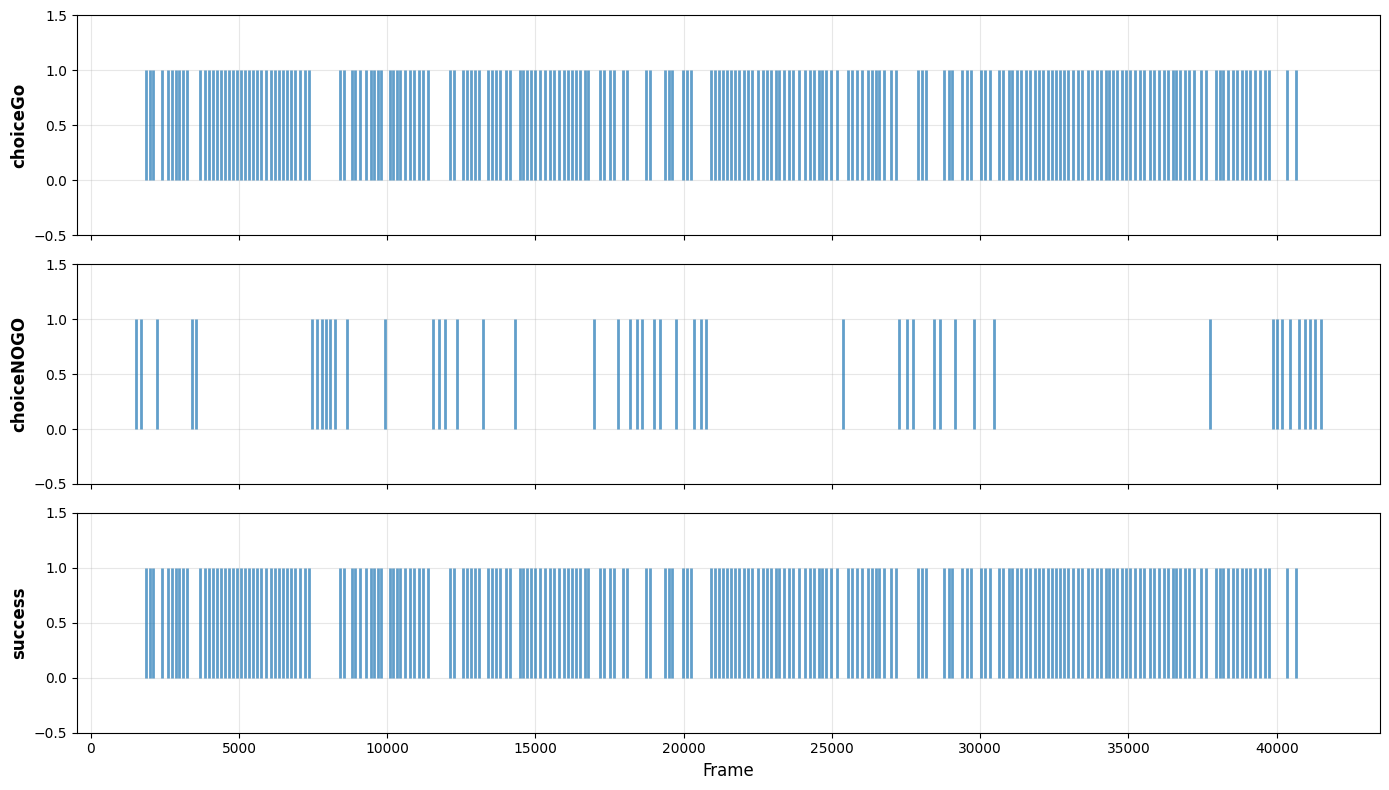

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i, label in enumerate(cogLabels):
    ax = axes[i]
    event_times = np.where(events[:, i])[0]
    ax.vlines(event_times, 0, 1, colors='C0', linewidth=2, alpha=0.7)
    ax.set_ylim(-0.5, 1.5)
    ax.set_ylabel(label, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:

def makeDesignMatrix_noTrials(events, eventType, regLabels, opts):
    """
    Python 1-to-1 translation of:

    [fullMat, eventIdx] = makeDesignMatrix_noTrials(events, eventType, regLabels, opts)

    events:      (nrTimes x nrRegs) binary/bool matrix
    eventType:   length nrRegs, values in {1,2,3}
    regLabels:   length nrRegs (strings)
    opts:        object with attributes OR dict with keys:
                preTrig, postTrig, sPostTime, mPreTime, mPostTime
    """

    # allow opts as dict or attribute-object
    def _get_opt(name):
        return opts[name] if isinstance(opts, dict) else getattr(opts, name)

    nrTimes = events.shape[0]
    nrRegs = len(eventType)

    # fullMat = cell(1,length(eventType)); eventIdx = cell(1,length(eventType));
    fullMat_cells = [None] * nrRegs
    eventIdx_cells = [None] * nrRegs

    # loop over regressor variables
    for iRegs in range(nrRegs):  # MATLAB: 1:nrRegs
        et = eventType[iRegs]

        # determine index for current event type
        if et == 1:
            # kernelIdx = -opts.preTrig : opts.postTrig;
            kernelIdx = np.arange(-_get_opt("preTrig"), _get_opt("postTrig") + 1, 1, dtype=int)
        elif et == 2:
            # kernelIdx = 0 : opts.sPostTime;
            kernelIdx = np.arange(0, _get_opt("sPostTime") + 1, 1, dtype=int)
        elif et == 3:
            # kernelIdx = -opts.mPreTime : opts.mPostTime;
            kernelIdx = np.arange(-_get_opt("mPreTime"), _get_opt("mPostTime") + 1, 1, dtype=int)
        else:
            raise ValueError("Unknown event type. Must be a value between 1 and 3.")

        # build design matrix
        nrCols = len(kernelIdx)
        trace = events[:, iRegs].astype(bool)             # trace = logical(events(:,iRegs));
        trace_idx = np.where(trace)[0] + 1                # MATLAB find(trace) (1-based indices)

        # cIdx = bsxfun(@plus, find(trace), kernelIdx);
        # -> (nEvents x nrCols) 1-based candidate indices
        cIdx = trace_idx[:, None] + kernelIdx[None, :]

        # fullMat{iRegs} = false(nrTimes, nrCols);
        mat = np.zeros((nrTimes, nrCols), dtype=bool)

        # for iCols = 1:nrCols
        for iCols in range(nrCols):
            useIdx = cIdx[:, iCols]  # 1-based
            # useIdx = useIdx(useIdx > 0 & useIdx <= nrTimes);
            useIdx = useIdx[(useIdx > 0) & (useIdx <= nrTimes)]
            # fullMat{iRegs}(useIdx, iCols) = true;
            # convert to 0-based for numpy indexing
            mat[useIdx - 1, iCols] = True

        # cIdx = sum(fullMat{iRegs},1) > 0; %don't use empty regressors
        keep_cols = np.sum(mat, axis=0) > 0

        # if sum(~cIdx) > 0 warning(...)
        removed = int(np.sum(~keep_cols))
        if removed > 0:
            warnings.warn(
                f"Removed {removed} empty regressors from design matrix of regressor {regLabels[iRegs]}."
            )

        # fullMat{iRegs} = fullMat{iRegs}(:,cIdx);
        mat = mat[:, keep_cols]

        # eventIdx{iRegs} = repmat(iRegs, sum(cIdx),1);
        # MATLAB iRegs is 1-based; keep that convention in eventIdx
        event_idx = np.full((int(np.sum(keep_cols)), 1), iRegs + 1, dtype=int)

        fullMat_cells[iRegs] = mat
        eventIdx_cells[iRegs] = event_idx

    # fullMat = cat(2,fullMat{:});
    fullMat = np.concatenate(fullMat_cells, axis=1) if nrRegs > 0 else np.zeros((nrTimes, 0), dtype=bool)

    # eventIdx = cat(1,eventIdx{:});
    eventIdx = np.concatenate(eventIdx_cells, axis=0) if nrRegs > 0 else np.zeros((0, 1), dtype=int)

    return fullMat, eventIdx

## Design Matrix Kernel Dimensions

### Kernel length formula
$$
\text{Kernel length} = \text{preTrig} + \text{postTrig} + 1
$$

### Parameters

- **Sampling rate:** 15.15 Hz  
- **preTrig:**  
 $$
  \lceil 15.15 \times 0.5 \rceil = 8 \text{ frames}
 $$

- **postTrig:**  
  $$
  \lceil 15.15 \times 8.0 \rceil = 122 \text{ frames}
  $$

### Columns per regressor

$$
8 + 122 + 1 = 131 \text{ columns}
$$


### Total regressors

We have 3 regressors:

- `choiceGo`
- `choiceNOGO`
- `success`

Each regressor contributes **131 temporal columns**:

- choiceGo → 131 columns  
- choiceNOGO → 131 columns  
- success → 131 columns  


### Final Design Matrix Size

$$
131 \times 3 = 393 \text{ total columns}
$$

So the full design matrix contains:

- **393 temporal regressors**

In [36]:

cogR, cogIdx = makeDesignMatrix_noTrials(events, eventType, cogLabels, opts)

In [37]:
cogR.shape

(41623, 393)

In [38]:
cogIdx.shape

(393, 1)

In [ ]:
np.unique(cogIdx)

array([1, 2, 3])

In [40]:
cogLabels

['choiceGo', 'choiceNOGO', 'success']

# make stimulus regressors

In [42]:
stimFreqs = np.unique(bhv.audioFreq)
stimFreqs

array([ 6, 11, 14], dtype=uint8)

In [43]:
stimLabels = [f"audioStim_{int(f)}kHz" for f in stimFreqs]
stimLabels

['audioStim_6kHz', 'audioStim_11kHz', 'audioStim_14kHz']

In [44]:
stimLabels = stimLabels + ['water']
stimLabels

['audioStim_6kHz', 'audioStim_11kHz', 'audioStim_14kHz', 'water']

In [46]:
eventType = np.full(len(stimLabels), 3, dtype=int)
eventType

array([3, 3, 3, 3])

In [47]:
events = np.zeros((Vc.shape[0], len(stimLabels)), dtype=bool)
events.shape

(41623, 4)

In [48]:
for iFreqs in range(len(stimFreqs)):  
    cIdx = (bhv.audioFreq == stimFreqs[iFreqs])
    events[:, iFreqs] = makeLogical(stimTimes[cIdx], Vc.shape[0])

cIdx.shape

(264,)

In [49]:
events[:, len(stimFreqs) + 0] = makeLogical(water, Vc.shape[0])

# events[:, len(stimFreqs) + 1] = makeLogical(punishTime, Vc.shape[0])

opts["mPreTime"] = opts["stimPreTime"]

opts["mPostTime"] = opts["stimPostTime"]

stimR, stimIdx = makeDesignMatrix_noTrials(events, eventType, stimLabels, opts)

stimIdx = stimIdx + np.max(cogIdx)

In [50]:
stimR.shape


(41623, 204)

In [51]:
stimIdx.shape

(204, 1)

In [52]:
np.unique(stimIdx)

array([4, 5, 6, 7])

In [53]:
stimLabels

['audioStim_6kHz', 'audioStim_11kHz', 'audioStim_14kHz', 'water']

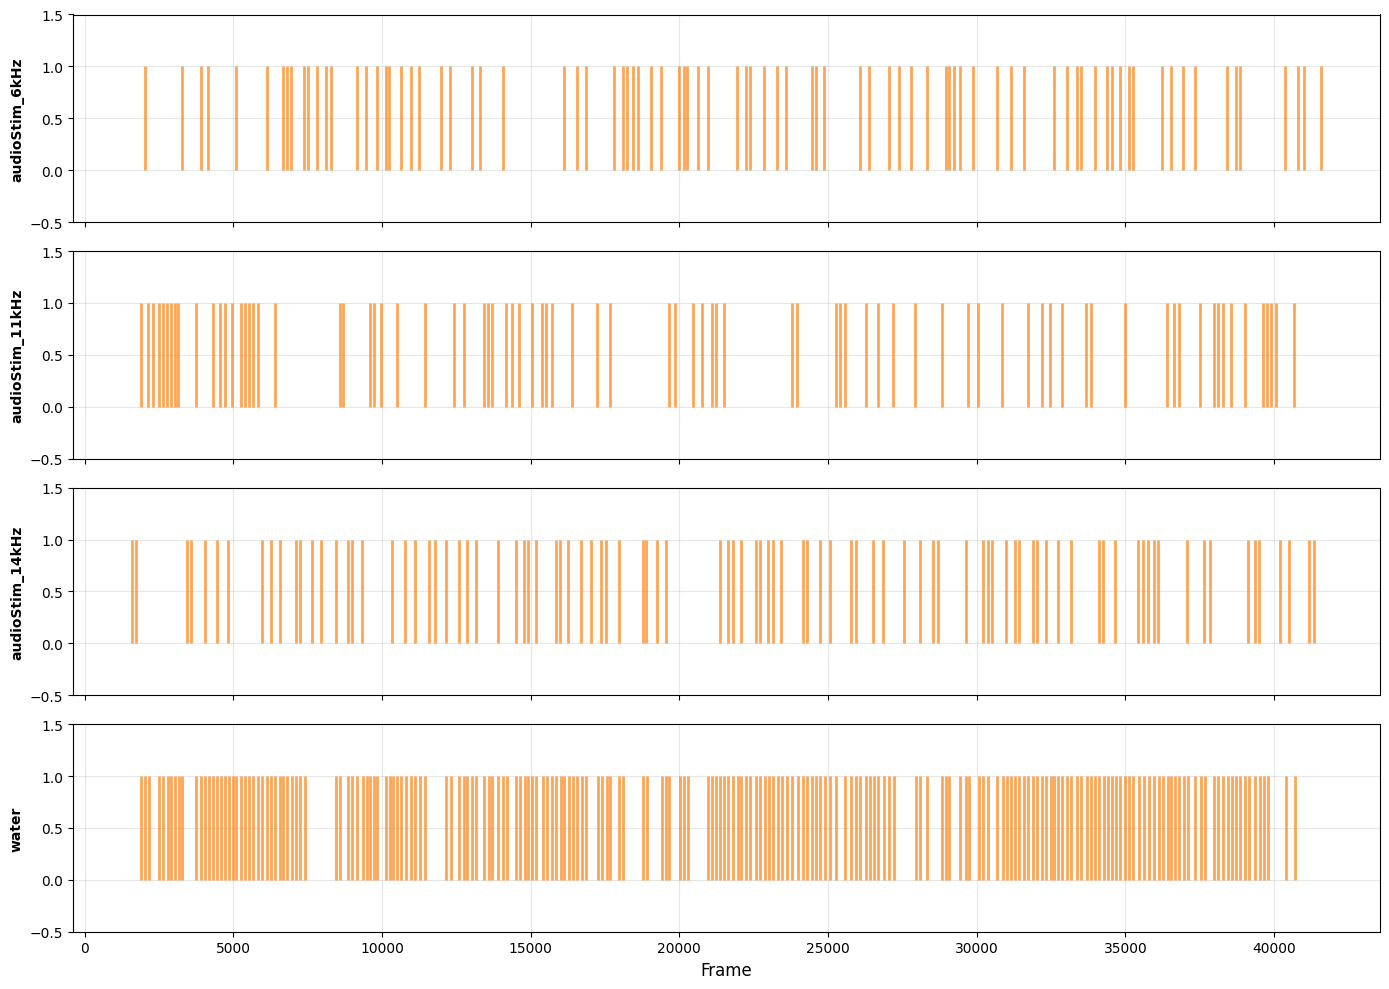

In [54]:
# Plot stimulus events
fig, axes = plt.subplots(len(stimLabels), 1, figsize=(14, 10), sharex=True)

for i, label in enumerate(stimLabels):
    ax = axes[i] if len(stimLabels) > 1 else axes
    event_times = np.where(events[:, i])[0]
    ax.vlines(event_times, 0, 1, colors='C1', linewidth=2, alpha=0.7)
    ax.set_ylim(-0.5, 1.5)
    ax.set_ylabel(label, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame', fontsize=12) if len(stimLabels) > 1 else axes.set_xlabel('Frame', fontsize=12)
plt.tight_layout()
plt.show()

# make dummy variable for shuffle control - based on timeR but shuffled for each regressor

In [55]:
dummyLabel = ['dummy']

dummyEvents = makeLogical(trialTimes, Vc.shape[0])

dummyR, dummyIdx = makeDesignMatrix_noTrials(
    dummyEvents[:, None],      # ensure column shape (nrTimes x 1)
    [3],                  # eventType = 3
    dummyLabel,
    opts
)

In [56]:
dummyR.shape

(41623, 51)

In [57]:
dummyIdx.shape

(51, 1)

In [58]:
dummyIdx = dummyIdx + np.max(stimIdx)

for iCol in range(dummyR.shape[1]):
    perm = np.random.permutation(dummyR.shape[0])
    dummyR[:, iCol] = dummyR[perm, iCol]

In [59]:
dummyIdx = dummyIdx.flatten()
dummyIdx

array([8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
       8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8,
       8, 8, 8, 8, 8, 8, 8])

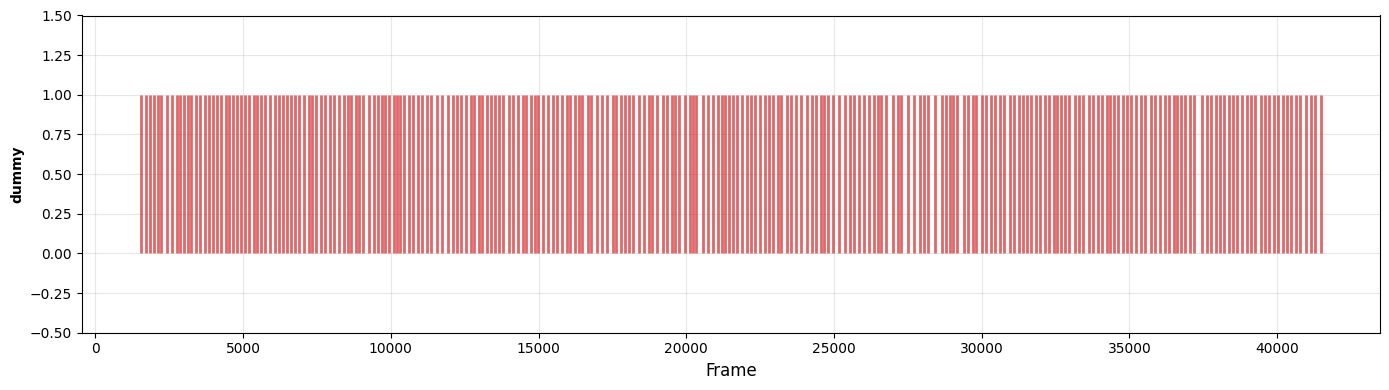

In [60]:
# Plot dummy events
fig, ax = plt.subplots(figsize=(14, 4))
event_times = np.where(dummyEvents)[0]
ax.vlines(event_times, 0, 1, colors='C3', linewidth=2, alpha=0.7)
ax.set_ylim(-0.5, 1.5)
ax.set_ylabel('dummy', fontsize=10, fontweight='bold')
ax.set_xlabel('Frame', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# make movement regressors

In [61]:
moveLabels = ['firstLicksR', 'nextLicksR']

In [62]:
eventType = np.full(len(moveLabels), 3, dtype=int)
eventType

array([3, 3])

In [63]:
events = np.zeros((Vc.shape[0], len(moveLabels)), dtype=bool)
events.shape


(41623, 2)

In [64]:
def cat2_cell(cell_list):
    """
    MATLAB: cat(2, cell{:})
    - ignores empty entries
    - concatenates contents horizontally into a 1D vector
    """
    out = []
    for x in cell_list:
        if x is None:
            continue
        # treat NaN as empty (if you used np.nan placeholders)
        if isinstance(x, float) and np.isnan(x):
            continue

        # scalar
        if np.isscalar(x):
            out.append(float(x))
        else:
            arr = np.asarray(x).ravel()
            # drop NaNs if present
            arr = arr[~np.isnan(arr)]
            out.extend(arr.astype(float).tolist())

    return np.asarray(out)

events[:, 0] = makeLogical(cat2_cell(firstLickR), Vc.shape[0])

events[:, 1] = makeLogical(cat2_cell(nextLickR), Vc.shape[0])


In [65]:
events.shape

(41623, 2)

In [66]:
events

array([[False, False],
       [False, False],
       [False, False],
       ...,
       [False, False],
       [False, False],
       [False, False]], shape=(41623, 2))

In [67]:
opts["mPreTime"] = opts["movePreTime"]

opts["mPostTime"] = opts["movePostTime"]

moveR, moveIdx = makeDesignMatrix_noTrials(events, eventType, moveLabels, opts)
moveIdx = moveIdx + np.max(dummyIdx)

In [ ]:
moveR.shape

(41623, 102)

In [68]:
moveIdx.shape

(102, 1)

In [70]:
np.unique(moveIdx)

array([ 9, 10])

In [71]:
moveLabels


['firstLicksR', 'nextLicksR']

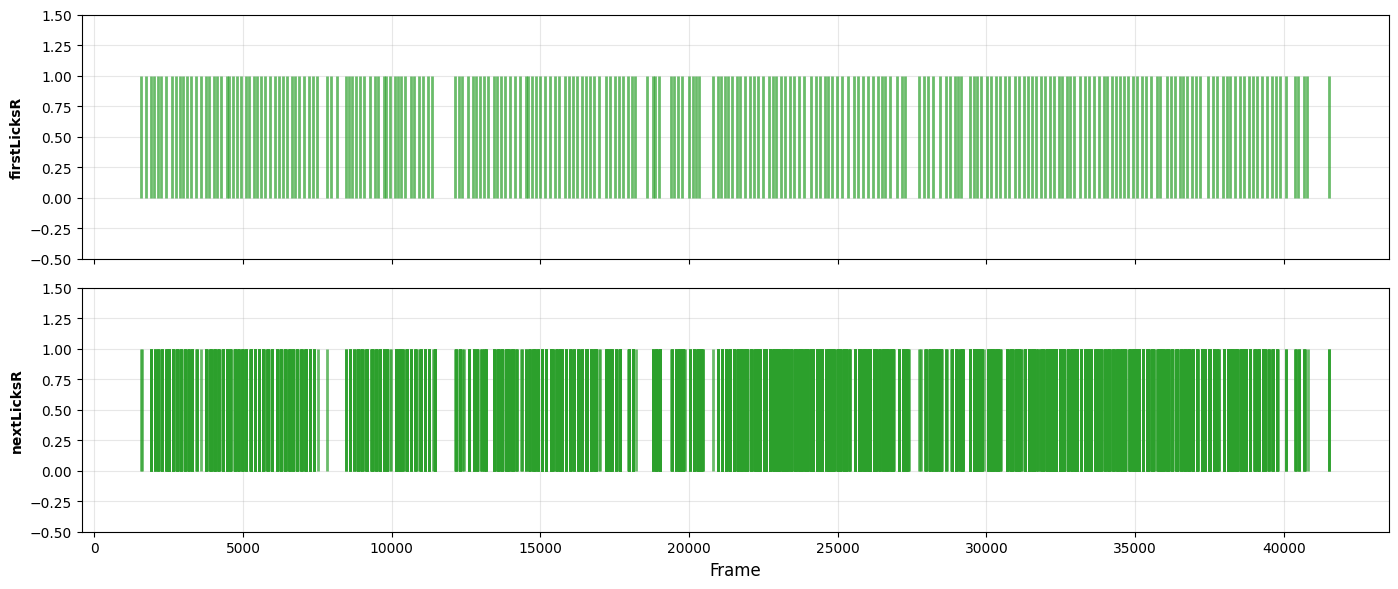

In [72]:
# Plot movement events
fig, axes = plt.subplots(len(moveLabels), 1, figsize=(14, 6), sharex=True)

for i, label in enumerate(moveLabels):
    ax = axes[i] if len(moveLabels) > 1 else axes
    event_times = np.where(events[:, i])[0]
    ax.vlines(event_times, 0, 1, colors='C2', linewidth=2, alpha=0.7)
    ax.set_ylim(-0.5, 1.5)
    ax.set_ylabel(label, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Frame', fontsize=12) if len(moveLabels) > 1 else axes.set_xlabel('Frame', fontsize=12)
plt.tight_layout()
plt.show()

#  merge all into one design matrix fullR

In [73]:
fullR = np.concatenate((cogR, stimR, dummyR, moveR), axis=1)

regLabels = cogLabels + stimLabels + dummyLabel + moveLabels


In [74]:
fullR.shape

(41623, 750)

In [75]:
regLabels

['choiceGo',
 'choiceNOGO',
 'success',
 'audioStim_6kHz',
 'audioStim_11kHz',
 'audioStim_14kHz',
 'water',
 'dummy',
 'firstLicksR',
 'nextLicksR']

In [76]:
cogIdx   = np.asarray(cogIdx).reshape(-1, 1)
print(cogIdx.shape)

stimIdx  = np.asarray(stimIdx).reshape(-1, 1)
print(stimIdx.shape)

dummyIdx = np.asarray(dummyIdx).reshape(-1, 1)
print(dummyIdx.shape)

moveIdx  = np.asarray(moveIdx).reshape(-1, 1)
print(moveIdx.shape)

regIdx = np.concatenate((cogIdx, stimIdx, dummyIdx, moveIdx), axis=0)

(393, 1)
(204, 1)
(51, 1)
(102, 1)


In [77]:
regIdx.shape

(750, 1)

In [78]:
np.unique(regIdx)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

#  run QR and check for rank-defficiency

In [81]:
rejIdx = np.nansum(np.abs(fullR), axis=0) < 10

R = fullR[:, ~rejIdx]

col_norm = np.sqrt(np.sum(R**2, axis=0))

R_norm = R / col_norm

_, fullQRR = np.linalg.qr(R_norm, mode='reduced')

In [82]:
rejIdx.shape

(750,)

In [83]:
# 1) Reject empty/weak regressors (MATLAB: nansum(abs(fullR)) < 10)
rejIdx = np.nansum(np.abs(fullR), axis=0) < 10

# 2) QR on normalized kept matrix (MATLAB: bsxfun(@rdivide, ..., sqrt(sum(...^2))))
Rkeep = fullR[:, ~rejIdx]

col_norm = np.sqrt(np.sum(Rkeep**2, axis=0))
# avoid divide-by-zero just in case (shouldn’t happen if rejIdx removed empties)
col_norm[col_norm == 0] = 1.0

X = Rkeep / col_norm

# MATLAB: [~, fullQRR] = qr(X,0)
_, fullQRR = np.linalg.qr(X, mode="reduced")

# 3) Rank deficiency check (MATLAB eps(fullQRR(1)) but eps is always positive)
showOrthplot = False
diagR = np.abs(np.diag(fullQRR))

# MATLAB linear indexing is column-major: fullQRR(1)
r1 = np.asarray(fullQRR).ravel(order="F")[0]

threshold = max(fullR.shape) * np.spacing(abs(r1))  # <-- critical fix
rank_mask = diagR > threshold

if np.sum(rank_mask) < fullQRR.shape[1]:
    temp = ~rank_mask  # regressors to remove among the currently-kept ones

    print(
        f"Design matrix is rank-deficient. Removing {np.sum(temp)}/{np.sum(~rejIdx)} additional regressors."
    )

    # MATLAB: rejIdx(~rejIdx) = temp
    good_idx = np.where(~rejIdx)[0]
    rejIdx[good_idx] = temp

    showOrthplot = True

print(f"Rejected {np.sum(rejIdx)}/{fullR.shape[1]} empty or redundant regressors")

Design matrix is rank-deficient. Removing 131/750 additional regressors.
Rejected 131/750 empty or redundant regressors


Design matrix is rank-defficient. Removing 131/750 additional regressors.


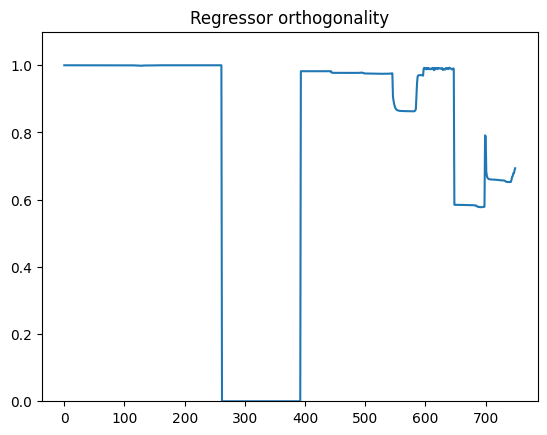

Rejected 131/750 empty or redundant regressors


In [ ]:
rejIdx = np.nansum(np.abs(fullR), axis=0) < 10

Rkeep = fullR[:, ~rejIdx]
col_norm = np.sqrt(np.sum(Rkeep**2, axis=0))
col_norm[col_norm == 0] = 1.0  # safety
X = Rkeep / col_norm

_, fullQRR = np.linalg.qr(X, mode="reduced")  # Q ignored, keep R

showOrthplot = False

diagR = np.abs(np.diag(fullQRR))

r1 = np.asarray(fullQRR).ravel(order="F")[0]
threshold = max(fullR.shape) * np.spacing(abs(r1))

rank_mask = diagR > threshold

if np.sum(rank_mask) < fullQRR.shape[1]:
    temp = ~rank_mask
    print(
        f"Design matrix is rank-defficient. Removing {np.sum(temp)}/{np.sum(~rejIdx)} additional regressors."
    )

    good_idx = np.where(~rejIdx)[0]
    rejIdx[good_idx] = temp
    showOrthplot = True

show_opt = opts["showOrthplot"] if isinstance(opts, dict) else getattr(opts, "showOrthplot")
if show_opt or showOrthplot:
    plt.figure()
    plt.plot(np.abs(np.diag(fullQRR)))
    plt.ylim([0, 1.1])
    plt.title("Regressor orthogonality")
    plt.show()

fullR = fullR[:, ~rejIdx] # reject regressors that are too sparse or rank-defficient

print(f"Rejected {np.sum(rejIdx)}/{len(rejIdx)} empty or redundant regressors")

In [101]:
fullR.shape

(41623, 619)

In [102]:
np.sum(rejIdx)

np.int64(131)

In [103]:
diag_vals = np.abs(np.diag(fullQRR))

threshold = max(fullR.shape) * np.spacing(abs(fullQRR.flat[0]))

zero_cols = np.where(diag_vals <= threshold)[0]

zero_regs = regIdx[zero_cols]

unique_regs = np.unique(zero_regs)

for r in unique_regs:
    print(r, regLabels[int(r)-1])

3 success


In [104]:
print("cogR:", cogR.shape)
print("stimR:", stimR.shape)
print("dummyR:", dummyR.shape)
print("moveR:", moveR.shape)

print("fullR:", fullR.shape)

cogR: (41623, 393)
stimR: (41623, 204)
dummyR: (41623, 51)
moveR: (41623, 102)
fullR: (41623, 619)


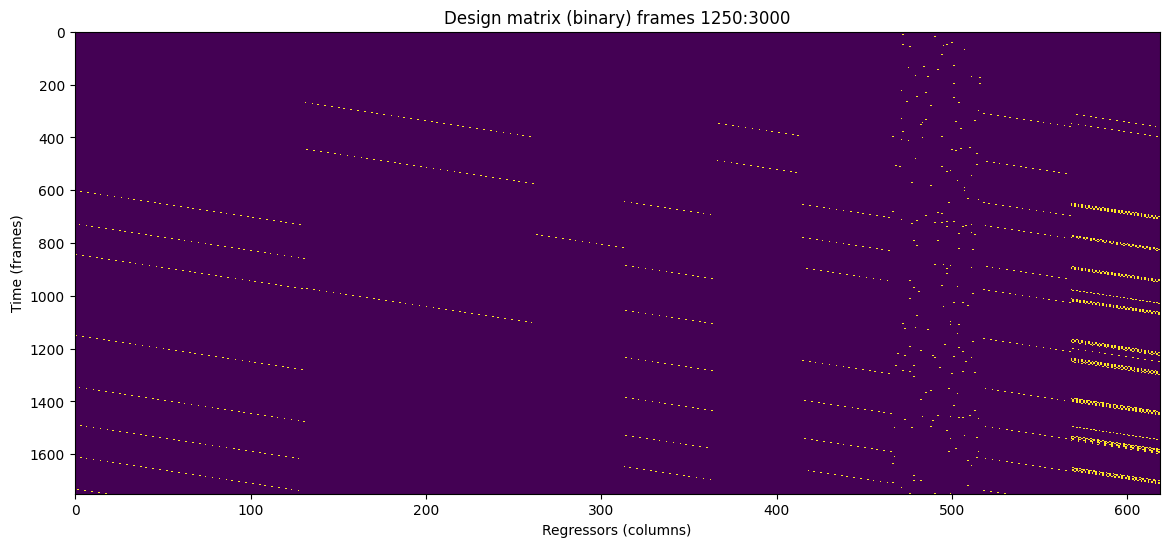

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a manageable window so it's readable
t0, t1 = 1250, 3000          # time window (frames)
x0, x1 = 0, fullR.shape[1] # regressor window (columns)

X = fullR[t0:t1, x0:x1]

plt.figure(figsize=(14, 6))
plt.imshow(X.astype(int), aspect="auto", interpolation="nearest",
           vmin=0, vmax=1)
plt.xlabel("Regressors (columns)")
plt.ylabel("Time (frames)")
plt.title(f"Design matrix (binary) frames {t0}:{t1}")
plt.show()

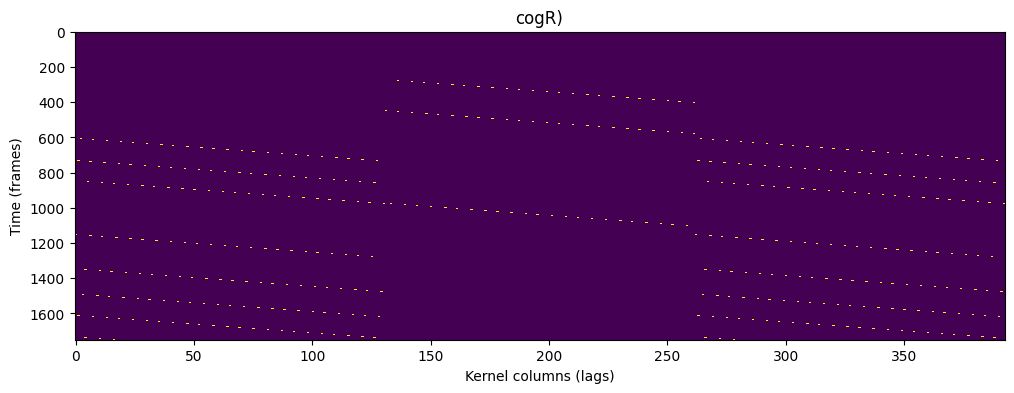

In [106]:

X = cogR[ 1250 :3000  , :]   # or stimR/moveR etc.

plt.figure(figsize=(12, 4))
plt.imshow(X.astype(int), aspect="auto", interpolation="nearest",
         vmin=0, vmax=1)
plt.xlabel("Kernel columns (lags)")
plt.ylabel("Time (frames)")
plt.title("cogR)")
plt.show()

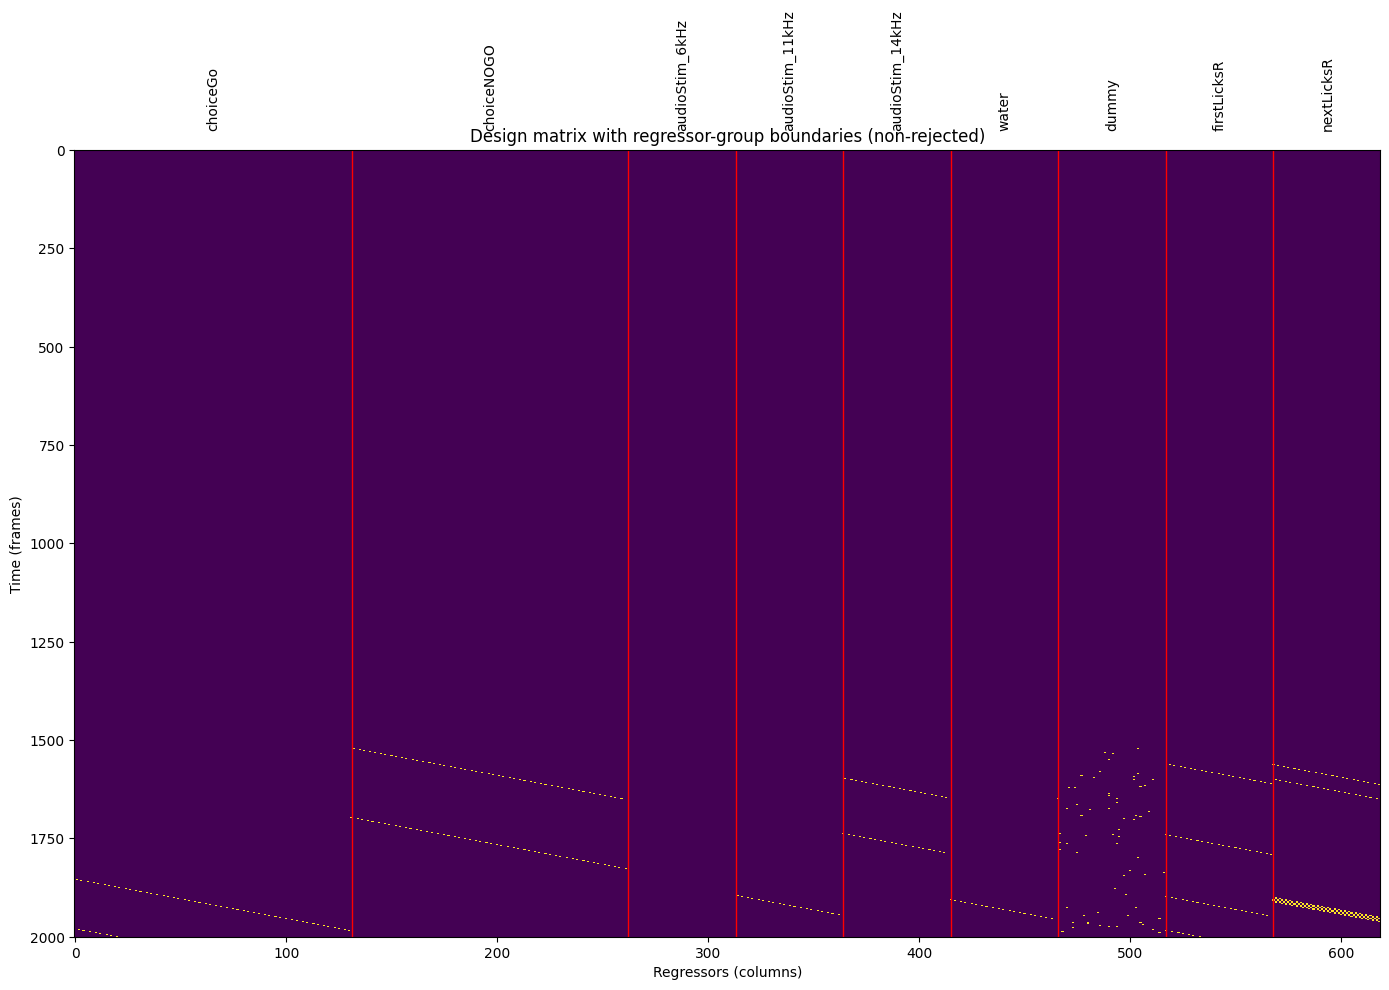

In [111]:
# Filter regIdx to only non-rejected columns
regIdx_kept = regIdx[~rejIdx]
regIdx_flat = regIdx_kept.flatten()

X = fullR

plt.figure(figsize=(14, 10))
plt.imshow(X.astype(int), aspect="auto", interpolation="nearest",
         vmin=0, vmax=1)

# find boundaries where regressor group changes
boundaries = np.where(np.diff(regIdx_flat))[0] + 1

# draw vertical boundary lines
for b in boundaries:
    plt.axvline(b, color="red", linewidth=1)

# compute block centers for labels
starts = np.concatenate(([0], boundaries))
ends = np.concatenate((boundaries, [len(regIdx_flat)]))
centers = (starts + ends) / 2

# add labels
for i, center in enumerate(centers):
    label = regLabels[int(regIdx_flat[int(starts[i])]) - 1]
    plt.text(center, -50, label,
             ha="center", va="bottom", rotation=90, fontsize=10)

plt.xlabel("Regressors (columns)")
plt.ylabel("Time (frames)")
plt.title("Design matrix with regressor-group boundaries (non-rejected)")
plt.ylim(2000, 0)  # optional: match MATLAB orientation
plt.tight_layout()
plt.show()

# Apply Rigde-GLM

In [109]:

def ridge_MML(Y, X, adjust_betas = False, recenter = True, L = None, regress = True):
    """
    This is an implementation of Ridge regression with the Ridge parameter
    lambda determined using the fast algorithm of Karabatsos 2017 (see
    below). I also made some improvements, described below.

    Inputs are Y (the outcome variables) and X (the design matrix, aka the
    regressors). Y may be a matrix. X is a matrix with as many rows as Y, and
    should *not* include a column of ones.

    A separate value of lambda will be found for each column of Y.

    Outputs are the lambdas (the Ridge parameters, one per column of Y); the
    betas (the regression coefficients, again with columns corresponding to
    columns of Y); and a vector of logicals telling you whether fminbnd
    failed to converge for each column of y (this happens frequently).

    If lambdas is supplied, the optimization step is skipped and the betas
    are computed immediately. This obviously speeds things up a lot.


    TECHNICAL DETAILS:

    To allow for un-centered X and Y, it turns out you can simply avoid
    penalizing the intercept when performing the regression. However, no
    matter what it is important to put the columns of X on the same scale
    before performing the regression (though Matlab's ridge.m does not do
    this if you choose not to recenter). This rescaling step is undone in the
    betas that are returned, so the user does not have to worry about it. But
    this step substantially improves reconstruction quality.

    Improvements to the Karabatsos algorithm: as lambda gets large, local
    optima occur frequently. To combat this, I use two strategies. First,
    once we've passed lambda = 25, we stop using the fixed step size of 1/4
    and start using an adaptive step size: 1% of the current lambda. (This
    also speeds up execution time greatly for large lambdas.) Second, we add
    boxcar smoothing to our likelihood values, with a width of 7. We still
    end up hitting local minima, but the lambdas we find are much bigger and
    closer to the global optimum.

    Source: "Marginal maximum likelihood estimation methods for the tuning
    parameters of ridge, power ridge, and generalized ridge regression" by G
    Karabatsos, Communications in Statistics -- Simulation and Computation,
    2017. Page 6.
    http://www.tandfonline.com/doi/pdf/10.1080/03610918.2017.1321119

    Written by Matt Kaufman, 2018. mattkaufman@uchicago.edu
    
    Adapted to Python by Michael Sokoletsky, 2021
    """
    
    ## Optional arguments

    if L is None:
        compute_L = True
    else:
        compute_L = False

    ## If design matrix is a DataFrame, convert to a matrix

    X = np.array(X)

    ## Error checking

    if np.size(Y, 0) != np.size(X, 0):
        raise IndexError('Size mismatch')

    ## Ensure Y is zero-mean

    pY = np.size(Y, 1)

    X[np.isnan(X)] = 0

    ## Renorm (Z-score) if adjusting betas (and if input to this function was not renormed already)
    if adjust_betas:
        X_std = np.std(X, axis=0, ddof=1)
        X = np.divide(X, X_std)
    
    # Recenter if not already done and computing L
    if not recenter and compute_L:
        X_mean = np.mean(X, 0)
        X = np.subtract(X, X_mean)


    ## Optimize lambda

    if compute_L:

        ## SVD the predictors

        U, d, VH = np.linalg.svd(X, full_matrices=False)
        S = np.diag(d)
        V = VH.T.conj()

        ## Find the valid singular values of X, compute d and alpha

        n = np.size(X, 0)  # Observations
        p = np.size(V, 1)  # Predictors

        # Find the number of good singular values. Ensure numerical stability.
        q = np.sum(d.T > abs(np.spacing(U[0,0])) * np.arange(1,p+1))

        d2 = d ** 2

        # Equation 1
        # Eliminated the diag(1 ./ d2) term: it gets cancelled later and only adds
        # numerical instability (since later elements of d may be tiny).
        # alph = V' * X' * Y
        alph = S @ U.T @ Y
        alpha2 = alph ** 2

        ## Compute variance of y
        # In Equation 19, this is shown as y'y

        Y_var = np.sum(Y ** 2, 0)

        ## Compute the lambdasnp.

        L = np.full(pY,np.nan)

        convergence_failures = np.empty(pY, dtype=int)
        
        for i in range(pY):
            
            L[i], flag = ridge_MML_one_Y(q, d2, n, Y_var[i], alpha2[:, i])
            convergence_failures[i] = flag
        
    else:
        p = np.size(X, 1)




    # If requested, perform the actual regression

    if regress:
        if not recenter:
            betas = np.full((p + 1, pY),np.nan)

            # Augment X with a column of ones, to allow for a non-zero intercept
            # (offset). This is what we'll use for regression, without a penalty on
            # the intercept column.

            X = np.c_[np.ones(np.size(X,0)), X]

            XTX = X.T @ X

            # Prep penalty matrix    
            ep = np.identity(p + 1)
            ep[0,0] = 0 # No penalty for intercept column

            # For renorming the betas
            # The 1 is so we don't renorm the intercept column.
            # Note that the rescaling doesn't alter the intercept.
            if adjust_betas:
                renorm = np.insert(X_std, 0, 1)

        else:
            betas = np.full((p, pY), np.nan)

            # You would think you could compute X'X more efficiently as VSSV', but
            # this is numerically unstable and can alter results slightly. Oh well.
            # XTX = V * bsxfun(@times, V', d2)

            XTX = X.T @ X

            # Prep penalty matrix
            ep = np.identity(p)

            if adjust_betas:
                # For renorming the betas
                renorm = X_std.T
            
        # Compute X' * Y all at once, again for speed
        XTY = X.T @ Y

        # Compute betas for renormed X
        if hasattr(L, "__len__"):
            for i in range(0, pY):
                betas[:, i] = np.linalg.solve(XTX + L[i] * ep, XTY[:, i])
        else:
            betas = np.linalg.solve(XTX + L * ep, XTY)
                
        if adjust_betas:
            # Adjust betas to account for renorming.
            betas = np.divide(betas.T, renorm).T

        betas[np.isnan(betas)] = 0



    ## Display fminbnd failures
    
    if compute_L and sum(convergence_failures) > 0:
        print(f'fminbnd failed to converge {sum(convergence_failures)}/{pY} times')
    
    if compute_L and regress:
        return L, betas
    if compute_L:
        return L
    return betas
    

def ridge_MML_one_Y(q, d2, n, Y_var, alpha2):
    
    # Compute the lambda for one column of Y

    # Width of smoothing kernel to use when dealing with large lambda
    
    smooth = 7

    # Value of lambda at which to switch from step size 1/4 to step size L/stepDenom.
    # Value of stepSwitch must be >= smooth/4, and stepSwitch/stepDenom should
    # be >= 1/4.
    step_switch = 25
    step_denom = 100
    
    ## Set up smoothing

    # These rolling buffers will hold the last few values, to average for smoothing
    sm_buffer = np.full(smooth, np.nan)
    test_vals_L = np.full(smooth, np.nan)

    # Initialize index of the buffers where we'll write the next value
    sm_buffer_I = 0
                
    
    # Evaluate the log likelihood of the data for increasing values of lambda
    # This is step 1 of the two-step algorithm at the bottom of page 6.
    # Basically, increment until we pass the peak. Here, I've added trying
    # small steps as normal, then switching over to using larger steps and
    # smoothing to combat local minima.
    
    ## Mint the negative log-likelihood function
    NLL_func = mint_NLL_func(q, d2, n, Y_var, alpha2)



    # Loop through first few values of k before you apply smoothing.
    # Step size 1/4, as recommended by Karabatsos

    done = False
    NLL = np.inf
    for k in range(step_switch * 4+1):
        sm_buffer_I = sm_buffer_I % smooth +1
        prev_NLL = NLL

      # Compute negative log likelihood of the data for this value of lambda
        NLL = NLL_func(k / 4)

      # Add to smoothing buffer
        sm_buffer[int(sm_buffer_I-1)] = NLL
        test_vals_L[int(sm_buffer_I-1)] = k / 4

      # Check if we've passed the minimum
        if NLL > prev_NLL:
            # Compute limits for L
            min_L = (k - 2) / 4
            max_L = k / 4
            done = True
            break
                        
    # If we haven't already hit the max likelihood, continue increasing lambda,
    # but now apply smoothing to try to reduce the impact of local minima that
    # occur when lambda is large

    # Also increase step size from 1/4 to L/stepDenom, for speed and robustness
    # to local minima
    
    if not done:
        
        L = k / 4
        NLL = np.mean(sm_buffer)
        iteration = 0
        
        while not done:
            L += L / step_denom
            sm_buffer_I = sm_buffer_I % smooth + 1
            prev_NLL = NLL
            iteration += 1
            # Compute negative log likelihood of the data for this value of lambda,
            # overwrite oldest value in the smoothing buffer
            sm_buffer[int(sm_buffer_I-1)] = NLL_func(L)
            test_vals_L[int(sm_buffer_I-1)] = L
            NLL = np.mean(sm_buffer)
            
            # Check if we've passed the minimum or hit NaN NLL (L passed double-precision maximum)
            
            if NLL>prev_NLL:
                # Adjust for smoothing kernel (walk back by half the kernel)
                sm_buffer_I -= (smooth - 1) / 2
                sm_buffer_I += smooth * (sm_buffer_I < 0) # wrap around
                
        
                max_L = test_vals_L[int(sm_buffer_I-1)]
            
                # Walk back by two more steps to find min bound
                sm_buffer_I -= 2
                sm_buffer_I += smooth * (sm_buffer_I < 0) # wrap around
                min_L = test_vals_L[int(sm_buffer_I-1)]

                passed_min = True
                done = True

            elif np.isnan(NLL):

                passed_min = False
                done = True
                
    else:

        passed_min = True

 
    ## Bounded optimization of lambda
    # This is step 2 of the two-step algorithm at the bottom of page 6. Note
    # that Karabatsos made a mistake when describing the indexing relative to
    # k*, which is fixed here (we need to go from k*-2 to k*, not k*-1 to k*+1)

    if passed_min:
        L, _, flag, _ = optimize.fminbound(NLL_func, max(0, min_L), max_L, xtol=1e-04, full_output=1, disp=0)
    else:
        flag = 1 # if the above loop could not find the minimum, return failed-to-converge flag
    
    return L, flag


def  mint_NLL_func(q, d2, n, Y_var, alpha2):
    '''
    Mint an anonymous function with L as the only input parameter, with all
    the other terms determined by the data.
    We've modified the math here to eliminate the d^2 term from both alpha
    (Equation 1, in main function) and here (Equation 19), because they
    cancel out and add numerical instability.
    '''
    NLL_func = lambda L: - (q * np.log(L) - np.sum(np.log(L + d2[:q])) \
                - n * np.log(Y_var - np.sum( np.divide(alpha2[:q],(L + d2[:q])))))
    return NLL_func


Fitting ridge model using RidgeCV
Optimal ridge penalty (alpha) from RidgeCV: 542.867544
Design matrix shape: (41623, 619)
Number of regressors (non-rejected): 619

=== Model Performance (Training Data) ===
Mean R² score: 0.0269 ± 0.0202
Median R² score: 0.0200
Min/Max R² score: 0.0051 / 0.1330

Mean MSE: 0.056794
Mean Pearson correlation: 0.1609 ± 0.0532

=== Cross-Validation Scores (5-fold) ===
Mean CV R² score: 0.0139 ± 0.0074
Individual fold scores: [0.00320998 0.01034942 0.01354269 0.02586142 0.01649857]


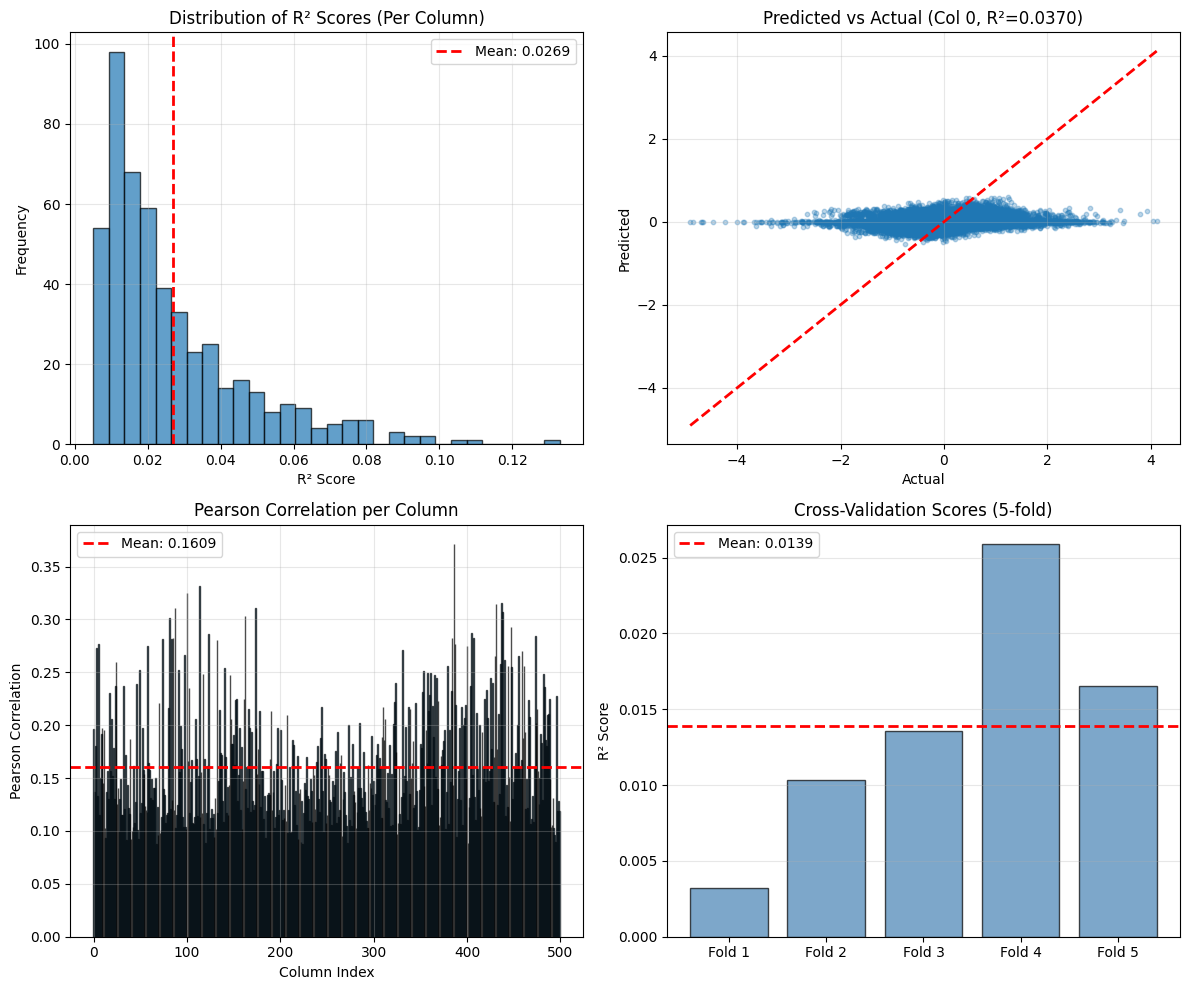

In [ ]:
import os
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from scipy.io import savemat
import matplotlib.pyplot as plt

savePath = r'E:\GLM_project\encoder_results'

def smoothCol_box(V, win=5):
    V = np.asarray(V, dtype=float)
    if win <= 1:
        return V
    kernel = np.ones(win, dtype=float) / win
    out = np.empty_like(V)
    for j in range(V.shape[1]):
        out[:, j] = np.convolve(V[:, j], kernel, mode="same")
    return out

# startIdx = find(sum([cogR, stimR] == 1, 2), 1);
taskR = np.concatenate((cogR, stimR), axis=1)
task_rows = np.sum(taskR == 1, axis=1)
startIdx0 = int(np.argmax(task_rows > 0)) if np.any(task_rows > 0) else 0

Vc[:startIdx0, :] = 0
fullR[:startIdx0, :] = 0

Vc = smoothCol_box(Vc, win=5)

newVc = Vc - np.mean(Vc, axis=0, keepdims=True)

print("Fitting ridge model using RidgeCV")
alphas = np.logspace(-2, 6, 50)
ridge = RidgeCV(alphas=alphas, fit_intercept=False, cv=5)
ridge.fit(fullR, newVc)

ridgeVal = float(ridge.alpha_)
dimBeta = ridge.coef_.T

print(f"Optimal ridge penalty (alpha) from RidgeCV: {ridgeVal:.6f}")
print(f"Design matrix shape: {fullR.shape}")
print(f"Number of regressors (non-rejected): {(~rejIdx).sum()}")

# Compute model predictions
Vm = fullR @ dimBeta

# Calculate goodness-of-fit metrics
print("\n=== Model Performance (Training Data) ===")

# R² score for each column of Vc
r2_scores = []
mse_scores = []
pearson_corrs = []

for i in range(newVc.shape[1]):
    # R² score
    r2 = r2_score(newVc[:, i], Vm[:, i])
    r2_scores.append(r2)
    
    # Mean Squared Error
    mse = mean_squared_error(newVc[:, i], Vm[:, i])
    mse_scores.append(mse)
    
    # Pearson correlation
    valid_idx = ~(np.isnan(newVc[:, i]) | np.isnan(Vm[:, i]))
    if np.sum(valid_idx) > 1:
        corr = np.corrcoef(newVc[valid_idx, i], Vm[valid_idx, i])[0, 1]
        pearson_corrs.append(corr)
    else:
        pearson_corrs.append(np.nan)

r2_scores = np.array(r2_scores)
mse_scores = np.array(mse_scores)
pearson_corrs = np.array(pearson_corrs)

print(f"Mean R² score: {np.nanmean(r2_scores):.4f} ± {np.nanstd(r2_scores):.4f}")
print(f"Median R² score: {np.nanmedian(r2_scores):.4f}")
print(f"Min/Max R² score: {np.nanmin(r2_scores):.4f} / {np.nanmax(r2_scores):.4f}")
print(f"\nMean MSE: {np.nanmean(mse_scores):.6f}")
print(f"Mean Pearson correlation: {np.nanmean(pearson_corrs):.4f} ± {np.nanstd(pearson_corrs):.4f}")

# Cross-validation scores
print("\n=== Cross-Validation Scores (5-fold) ===")
ridge_cv = RidgeCV(alphas=alphas, fit_intercept=False, cv=5)
cv_scores = cross_val_score(ridge_cv, fullR, newVc, cv=5, scoring='r2')
print(f"Mean CV R² score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(f"Individual fold scores: {cv_scores}")

# Visualize performance
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Distribution of R² scores
axes[0, 0].hist(r2_scores, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.nanmean(r2_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.nanmean(r2_scores):.4f}')
axes[0, 0].set_xlabel('R² Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of R² Scores (Per Column)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Predicted vs Actual for first column
axes[0, 1].scatter(newVc[:, 0], Vm[:, 0], alpha=0.3, s=10)
axes[0, 1].plot([newVc[:, 0].min(), newVc[:, 0].max()], [newVc[:, 0].min(), newVc[:, 0].max()], 'r--', linewidth=2)
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].set_title(f'Predicted vs Actual (Col 0, R²={r2_scores[0]:.4f})')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Pearson correlations
axes[1, 0].bar(range(len(pearson_corrs)), pearson_corrs, edgecolor='black', alpha=0.7)
axes[1, 0].axhline(np.nanmean(pearson_corrs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.nanmean(pearson_corrs):.4f}')
axes[1, 0].set_xlabel('Column Index')
axes[1, 0].set_ylabel('Pearson Correlation')
axes[1, 0].set_title('Pearson Correlation per Column')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: CV scores across folds
fold_names = [f'Fold {i+1}' for i in range(len(cv_scores))]
axes[1, 1].bar(fold_names, cv_scores, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 1].axhline(np.mean(cv_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(cv_scores):.4f}')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('Cross-Validation Scores (5-fold)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

os.makedirs(savePath, exist_ok=True)
savemat(os.path.join(savePath, "dimBeta.mat"), {"dimBeta": dimBeta, "ridgeVals": ridgeVal})
savemat(os.path.join(savePath, "regData.mat"), {
    "fullR": fullR, "rejIdx": rejIdx, "regIdx": regIdx,
    "regLabels": np.array(regLabels, dtype=object),
    "fullQRR": fullQRR, "bhv": bhv, "trialTimes": trialTimes,
    "stimTimes": stimTimes, "opts": opts
})
savemat(os.path.join(savePath, "rawVc.mat"), {"newVc": newVc})
savemat(os.path.join(savePath, "modelMetrics.mat"), {
    "r2_scores": r2_scores, "mse_scores": mse_scores, "pearson_corrs": pearson_corrs,
    "cv_scores": cv_scores, "mean_r2": np.nanmean(r2_scores), "mean_cv_r2": np.mean(cv_scores)
})

In [ ]:
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score

# Fit Ridge regression using RidgeCV
ridge_model = RidgeCV(alphas=np.logspace(-2, 6, 50), cv=5)
ridge_model.fit(fullR, newVc)

# Get predictions
predictions = ridge_model.predict(fullR)

# Calculate R² score
r2 = r2_score(newVc, predictions)
print(f"R² Score: {r2:.4f}")
print(f"Best alpha: {ridge_model.alpha_:.4f}")

# Cross-validation R² scores
cv_r2 = cross_val_score(ridge_model, fullR, newVc, cv=5, scoring='r2')
print(f"Cross-validation R² scores: {cv_r2}")
print(f"Mean CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

R² Score: 0.0259
Best alpha: 790.6043
